# Analysis of Ship Wreck Data from the Roman Empire
## Gene Foxwell
## Dataset: https://oxrep.classics.ox.ac.uk/databases/shipwrecks_database/0to20/

Strauss, J. (2013). Shipwrecks Database. Version 1.0. Accessed (date): oxrep.classics.ox.ac.uk/databases/shipwrecks_database/

## Dataset Overview

We will use this dataset to search for patterns in Roman Shipwrecks. We are interested in where they happened, and the characteristics of the ships that they happened to. To this end, we are interested in the following fields:

* **Wreck ID**: Allows us to reference the ship wreck.
* **Sea area**: Tells us what area of the sea the wreck happened in.
* **Lattitude & Longitude**: Rough estimates of the wrecks location. (This were kept impercise in the dataset to discourage looting)
* **Estimated tonnage**: Roughly how large this ship was.
* **Place of origin**: Where the ship was coming from.
* **Place of destination**: Where the ship was going.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Loading in the csv and checking the first few rows to make sure everything is as expected...

In [43]:
df = pd.read_csv("data/StraussShipwrecks.csv")
df.head()

,Wreck ID,Strauss ID,Name,Parker Number,Sea area,Country,Region,Latitude,Longitude,Min depth,...,Columns etc,Sarcophagi,Blocks,Marble type,Other cargo,Hull remains,Shipboard paraphernalia,Ship equipment,Estimated tonnage,Amphora type
0,1,331,Komiza,NaN,Adriatic,Croatia,Vis Island,43.03333,16.08333,30.0,...,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,328,Lokunji,NaN,Adriatic,Croatia,Kvarner region,44.70000,14.28333,4.0,...,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,329,Maharac Cape,NaN,Adriatic,Croatia,Mljet island,42.73333,17.66666,3.0,...,False,False,False,NaN,Eastern coarse ware pottery of biconical dishe...,NaN,NaN,NaN,NaN,NaN
3,4,330,Mlin,702,Adriatic,Croatia,Split channel,43.45000,16.23333,25.0,...,False,False,False,NaN,NaN,Remains of the hull.,NaN,"Two lead anchor stocks, though possibly not fr...",NaN,NaN
4,5,322,Plavac B,832,Adriatic,Croatia,"Zlarin Island, central Dalmatia",NaN,NaN,NaN,...,False,False,False,NaN,NaN,NaN,NaN,.,NaN,NaN


Get some basic information on the dataframe - how many rows, what are the columns? Data types for those columns...

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1784 entries, 0 to 1783
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Wreck ID                 1784 non-null   int64  
 1   Strauss ID               1784 non-null   int64  
 2   Name                     1784 non-null   object 
 3   Parker Number            1259 non-null   object 
 4   Sea area                 572 non-null    object 
 5   Country                  916 non-null    object 
 6   Region                   739 non-null    object 
 7   Latitude                 1601 non-null   float64
 8   Longitude                1603 non-null   float64
 9   Min depth                607 non-null    float64
 10  Max depth                608 non-null    float64
 11  Depth                    583 non-null    object 
 12  Period                   754 non-null    object 
 13  Dating                   767 non-null    object 
 14  Earliest date           

Clean the data to make Exploratory Data Analsys a little easier...

In [45]:
def prepare_shipwreck_data(df_source):
    """
    Drops columns that we won't be using from the dataframe.

    Args:
        df_source: the source dataframe.
    Returns:
        A new dataframe with only the expected columns.
    """    
    df_results = df_source.copy()

    df_results = df_results.drop(columns=["Strauss ID", 
                                          "Country",
                                          "Region",
                                          "Parker Number", 
                                          "Depth", 
                                          "Period", 
                                          "Dating", 
                                          "Earliest date",
                                          "Latest date",
                                          "Date range",
                                          "Mid point of date range", 
                                          "Probability", 
                                          "Reference", 
                                          "Comments", 
                                          "Amphorae", 
                                          "Marble",
                                          "Columns etc",
                                          "Sarcophagi",
                                          "Blocks",
                                          "Marble type",
                                          "Other cargo",
                                          "Hull remains",
                                          "Shipboard paraphernalia",
                                          "Ship equipment",
                                          "Min depth",
                                          "Max depth",
                                          "Amphora type"
                                        ])

    return df_results

In [46]:
df_shipwreck_data = prepare_shipwreck_data(df)
df_shipwreck_data.head()

,Wreck ID,Name,Sea area,Latitude,Longitude,Place of origin,Place of destination,Estimated tonnage
0,1,Komiza,Adriatic,43.03333,16.08333,Egypt,Northern Italy,NaN
1,2,Lokunji,Adriatic,44.70000,14.28333,Cos,Northern Italy,NaN
2,3,Maharac Cape,Adriatic,42.73333,17.66666,Rhodes,Northern Italy,NaN
3,4,Mlin,Adriatic,43.45000,16.23333,Aegean,Northern Italy,NaN
4,5,Plavac B,Adriatic,NaN,NaN,NaN,NaN,NaN


### **RQ1:** What sea area's saw the most known Roman Ship Wrecks? 

In [47]:
df_shipwreck_data["Sea area"].unique()

array(['Adriatic', 'Western Mediterranean', 'Tyrrhenian Sea',
       'Central Mediterranean', 'Aegean', 'Eastern Mediterranean',
       'Black Sea', 'Red Sea', 'Indian Ocean', nan, 'Ionian',
       'West Mediterranean', 'Southern Aegean', 'Northern Aegean'],
      dtype=object)

In [48]:
def plot_sea_area_chart(df_source):
    value_counts = df_source["Sea area"].value_counts()

    value_counts.plot(kind="bar", color="black", edgecolor="black")
    plt.xlabel("Sea Area")
    plt.ylabel("Count")
    plt.title("Roman Shipwrecks by Sea Area")

    plt.savefig("shipwrecks_seaarea.png");

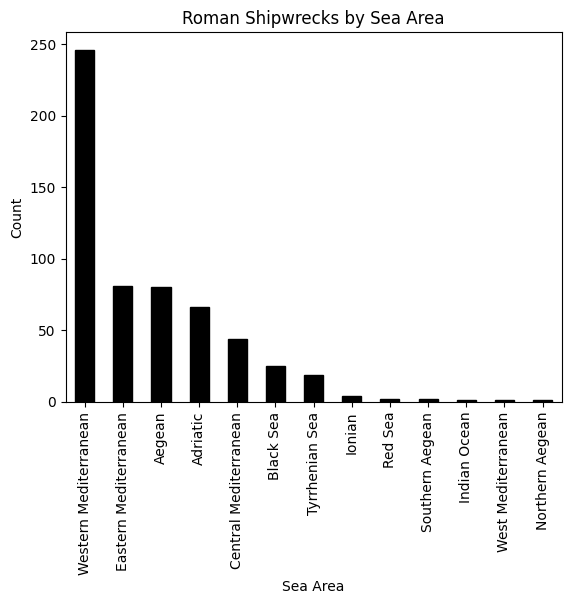

In [49]:
plot_sea_area_chart(df_shipwreck_data)

### **RQ2:** What is the distribution of ship tonnages amongst Roman Ship Wrecks?

In [50]:
def plot_tonnage_chart(df_source):
    tonnage_data = df_source["Estimated tonnage"]
    
    min_tonnage = df["Estimated tonnage"].min()
    max_tonnage = df["Estimated tonnage"].max()
    bins = np.arange(min_tonnage, max_tonnage + 2, 25)

    tonnage_data.plot(kind='hist', color='black', edgecolor='black', bins=bins)
    plt.xlabel("Tonnage")
    plt.ylabel("Frequency")
    plt.title("Roman Ship Wrecks by Tonnage")
    
    plt.savefig("shipwrecks_tonnage.png");

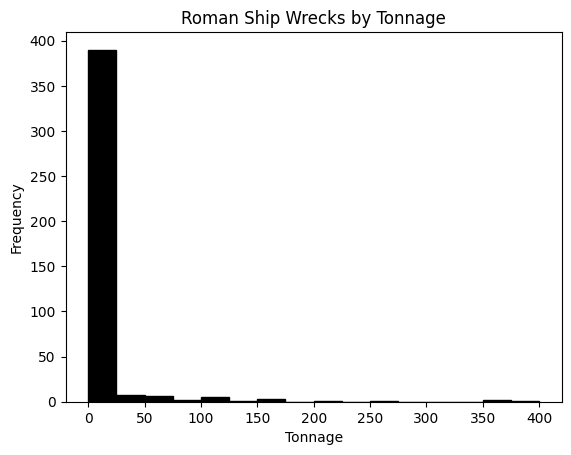

In [51]:
plot_tonnage_chart(df_shipwreck_data)

It seems most of the ship wrecks were for ships under 25 tonnes. Does the sea area of the ship wreck effect the tonnage? Lets see if we can find out...

### **RQ3:** What, if anything, is the relationship between Sea Area and Tonnage?

Let's start by looking at the average tonnage per sea area:

In [52]:
def plot_mean_tonnage_by_area(df_source):
    average_tonnages = df_source.groupby("Sea area")["Estimated tonnage"].mean()
    average_tonnages.dropna(inplace=True)

    average_tonnages.plot(kind="bar", color="black")
    plt.title("Mean Roman Ship Wreck Tonnage by Sea Area")
    plt.xlabel("Sea Area")
    plt.ylabel("Mean Tonnage")

    plt.savefig("shipwrecks_tonnage_area.png");

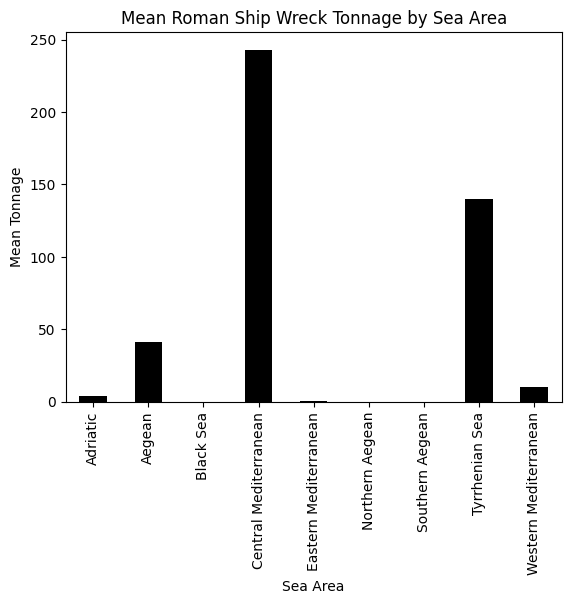

In [53]:
plot_mean_tonnage_by_area(df_shipwreck_data)